# 02 — Preprocessing

**Input:** `data/raw/raw_data.csv` (includes BuyLaptop target field)  
**Output:** `data/processed/processed_data.csv` (8 features, scaled; target handled separately)

Steps:
1. Drop `ID`
2. Separate target variable (`BuyLaptop`) from features
3. Impute missing values
4. Outlier detection & removal (IQR method)
5. Encode categoricals (keep BuyLaptop as-is)
6. Feature scaling (StandardScaler) — applied ONLY to features, not target


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

PLOT_DIR = Path('../plots/preprocessing')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv('../data/raw/raw_data.csv')
print('Raw shape:', df.shape)
df.head()

Raw shape: (12872, 10)


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,BuyLaptop
0,459369,Male,Yes,40,No,Engineer,NaN,Average,6.0,Yes
1,463049,Male,Yes,51,No,Executive,4.0,High,4.0,Yes
2,465015,Female,Yes,61,Yes,Engineer,0.0,Low,3.0,No
3,467962,Female,No,20,No,Healthcare,0.0,Low,NaN,No
4,461987,Female,Yes,43,No,Engineer,1.0,Average,2.0,Yes


## Step 1:  Drop Unused Columns

In [ ]:
df = df.drop(columns=['ID'], errors='ignore')
print('After drop:', df.shape)

After drop: (12872, 9)


## Step 1b: Separate Target Variable

In [ ]:
# Separate target variable (BuyLaptop) from features
# BuyLaptop should NOT be scaled — it's a classification target
if 'BuyLaptop' in df.columns:
    y = df['BuyLaptop'].copy()  # Save target variable
    df_features = df.drop(columns=['BuyLaptop'])
    print(f"Target (BuyLaptop) separated.")
    print(f"  Distribution: {y.value_counts().to_dict()}")
else:
    print("Warning: BuyLaptop column not found. Proceeding without target variable.")

Target (BuyLaptop) separated.
  Distribution: {'Yes': 6436, 'No': 6436}


## Step 2: Handle Missing Values

In [ ]:
print('Missing before imputation:')
print(df_features.isnull().sum()[df_features.isnull().sum() > 0])

# Numeric: fill with median
num_cols = df_features.select_dtypes(include='number').columns.tolist()
for col in num_cols:
    df_features[col].fillna(df_features[col].median(), inplace=True)

# Categorical: fill with mode
cat_cols = df_features.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df_features[col].fillna(df_features[col].mode()[0], inplace=True)

print('\nMissing after imputation:', df_features.isnull().sum().sum())

Missing before imputation:
Ever_Married        286
Graduated           116
Profession          168
Work_Experience    1398
Family_Size         450
dtype: int64

Missing after imputation: 0


## Step 3 : Outlier Detection & Removal (IQR)

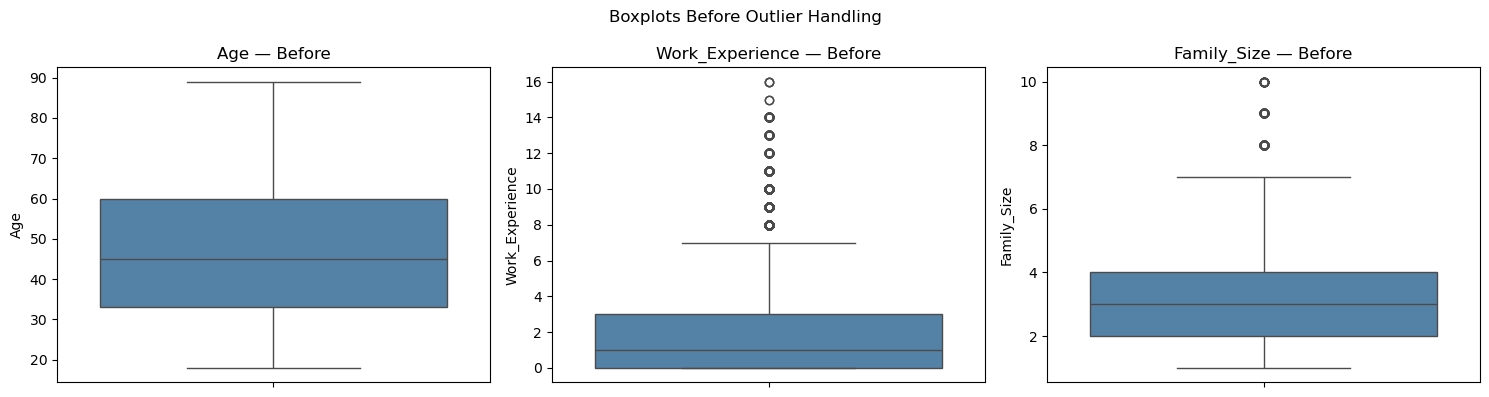

In [ ]:
# --- Boxplots BEFORE handling ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Age', 'Work_Experience', 'Family_Size']):
    sns.boxplot(y=df_features[col], ax=ax, color='steelblue')
    ax.set_title(f'{col} — Before')
plt.suptitle('Boxplots Before Outlier Handling')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'boxplots_before_outlier_handling.png', dpi=150)
plt.show()

In [ ]:
# IQR Capping (Winsorization) — cap outliers at 1.5*IQR fences
outlier_cols = ['Age', 'Work_Experience', 'Family_Size']

for col in outlier_cols:
    Q1  = df_features[col].quantile(0.25)
    Q3  = df_features[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = df_features[col].shape[0]
    outliers = ((df_features[col] < lower) | (df_features[col] > upper)).sum()
    # Cap (winsorise) instead of drop — preserves row count
    df_features[col] = df_features[col].clip(lower=lower, upper=upper)
    print(f'{col}: {outliers} outliers capped  (lower={lower:.1f}, upper={upper:.1f})')

Age: 0 outliers capped  (lower=-7.5, upper=100.5)
Work_Experience: 1601 outliers capped  (lower=-4.5, upper=7.5)
Family_Size: 176 outliers capped  (lower=-1.0, upper=7.0)


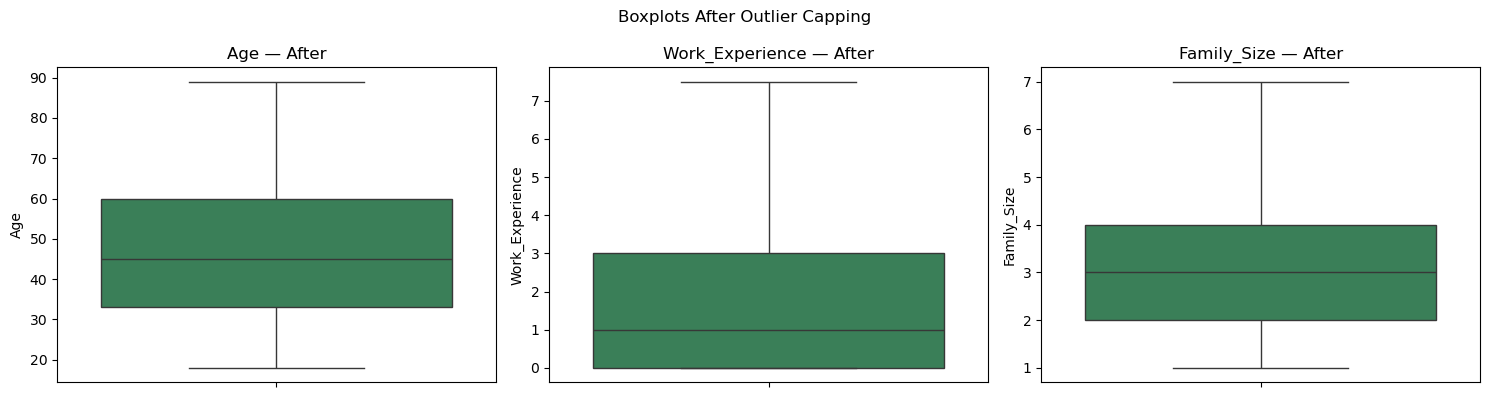

In [ ]:
# --- Boxplots AFTER handling ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Age', 'Work_Experience', 'Family_Size']):
    sns.boxplot(y=df_features[col], ax=ax, color='seagreen')
    ax.set_title(f'{col} — After')
plt.suptitle('Boxplots After Outlier Capping')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'boxplots_after_outlier_capping.png', dpi=150)
plt.show()

## Step 4 : Encode Categoricals

In [ ]:
le = LabelEncoder()

# Normalize categorical text for consistent mapping
cat_normalize_cols = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score']
for col in cat_normalize_cols:
    if col in df_features.columns:
        df_features[col] = df_features[col].astype(str).str.strip().str.capitalize()

# Ordinal encoding for Spending_Score
spending_map = {'Low': 0, 'Average': 1, 'High': 2}
if 'Spending_Score' in df_features.columns:
    df_features['Spending_Score'] = df_features['Spending_Score'].map(spending_map)

# Binary encoding — only on feature columns (do not include target)
binary_map = {'Male': 1, 'Female': 0, 'Yes': 1, 'No': 0}
for col in ['Gender', 'Ever_Married', 'Graduated','BuyLaptop']:
    if col in df_features.columns:
        df_features[col] = df_features[col].map(binary_map)

# Label encode remaining object columns (e.g., Profession)
for col in df_features.select_dtypes(include='object').columns:
    df_features[col] = le.fit_transform(df_features[col].astype(str))

print('Dtypes after encoding:')
print(df_features.dtypes)
df_features.head()

Dtypes after encoding:
Gender               int64
Ever_Married         int64
Age                  int64
Graduated            int64
Profession           int64
Work_Experience    float64
Spending_Score       int64
Family_Size        float64
dtype: object


,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size
0,1,1,40,0,2,1.0,1,6.0
1,1,1,51,0,4,4.0,2,4.0
2,0,1,61,1,2,0.0,0,3.0
3,0,0,20,0,5,0.0,0,3.0
4,0,1,43,0,2,1.0,1,2.0


In [ ]:
# Diagnostic: inspect raw df and df_features values after encoding
print('Raw df (first 5 rows):')
display(df.head())
print('\nProcessed feature DF (first 5 rows):')
display(df_features.head())

for col in ['Gender','Ever_Married','Graduated','Spending_Score']:
    if col in df_features.columns:
        print(f"\nUnique values for {col} (sample):", pd.Series(df_features[col]).unique()[:20])

Raw df (first 5 rows):


,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,BuyLaptop
0,Male,Yes,40,No,Engineer,NaN,Average,6.0,Yes
1,Male,Yes,51,No,Executive,4.0,High,4.0,Yes
2,Female,Yes,61,Yes,Engineer,0.0,Low,3.0,No
3,Female,No,20,No,Healthcare,0.0,Low,NaN,No
4,Female,Yes,43,No,Engineer,1.0,Average,2.0,Yes



Processed feature DF (first 5 rows):


,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size
0,1,1,40,0,2,1.0,1,6.0
1,1,1,51,0,4,4.0,2,4.0
2,0,1,61,1,2,0.0,0,3.0
3,0,0,20,0,5,0.0,0,3.0
4,0,1,43,0,2,1.0,1,2.0



Unique values for Gender (sample): [1 0]

Unique values for Ever_Married (sample): [1 0]

Unique values for Graduated (sample): [0 1]

Unique values for Spending_Score (sample): [1 2 0]


## Step 5 : Feature Scaling (StandardScaler)

In [ ]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_features), columns=df_features.columns)

# Add the target variable back (unscaled) for classification training
if 'BuyLaptop' in locals():
    df_scaled['BuyLaptop'] = y.reset_index(drop=True).values
    print("✓ Target variable (BuyLaptop) added to scaled data")

print('\nScaled stats (mean ≈ 0, std ≈ 1):')
df_scaled.describe().round(2)


Scaled stats (mean ≈ 0, std ≈ 1):


,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size
count,12872.00,12872.00,12872.00,12872.00,12872.00,12872.00,12872.00,12872.00
mean,-0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.10,-1.56,-1.68,-1.27,-1.17,-0.83,-1.15,-1.31
25%,-1.10,-1.56,-0.82,-1.27,-1.17,-0.83,-1.15,-0.63
50%,0.91,0.64,-0.13,0.79,0.01,-0.45,0.01,0.05
75%,0.91,0.64,0.73,0.79,0.79,0.32,1.17,0.74
max,0.91,0.64,2.39,0.79,1.97,2.04,1.17,2.78


## Correlation Heatmap (after processing)

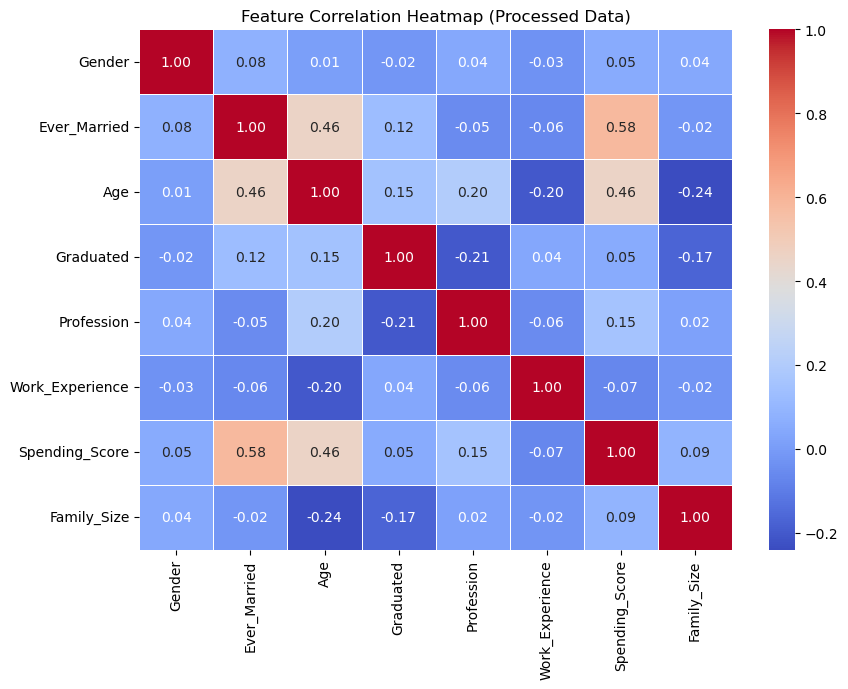

In [ ]:
plt.figure(figsize=(9, 7))
# Correlation of features only (exclude target if present)
df_for_corr = df_scaled.drop(columns=['BuyLaptop'], errors='ignore')
sns.heatmap(df_for_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap (Processed Data)')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'correlation_heatmap_processed_data.png', dpi=150)
plt.show()

## Save Processed Data

In [ ]:
# Save processed data with binary BuyLaptop
df_scaled['BuyLaptop'] = y.map({'Yes': 1, 'No': 0}).values
df_scaled.to_csv('../data/processed/processed_data.csv', index=False)
print(f'✓ Saved processed_data.csv with features + binary BuyLaptop — shape: {df_scaled.shape}')
print(f'  Columns: {list(df_scaled.columns)}')
print(f'  BuyLaptop distribution: {df_scaled["BuyLaptop"].value_counts().to_dict()}')

# Save preprocessing artifacts for API inference
import pickle
import os

models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

# Save scaler
with open(os.path.join(models_dir, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
print(f'✓ Saved scaler.pkl')

# Save preprocessing config: mappings and encoder for Profession
preprocess_config = {
    'binary_map': {'Male': 1, 'Female': 0, 'Yes': 1, 'No': 0},
    'spending_map': {'Low': 0, 'Average': 1, 'High': 2},
    'profession_encoder': le  # LabelEncoder trained on Profession values
}

with open(os.path.join(models_dir, 'encoders.pkl'), 'wb') as f:
    pickle.dump(preprocess_config, f)
print(f'✓ Saved encoders.pkl with preprocessing config')

✓ Saved processed_data.csv with features + binary BuyLaptop — shape: (12872, 9)
  Columns: ['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Work_Experience', 'Spending_Score', 'Family_Size', 'BuyLaptop']
  BuyLaptop distribution: {1: 6436, 0: 6436}
✓ Saved scaler.pkl
✓ Saved encoders.pkl with preprocessing config
